# Fine-Tuning

# Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance

# Downsteam XGBoost

# Using Fine-Tuned Model (after training)

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_poisson_deviance

# Load Data
# ---------------------------------------------------------
train_df = np.load("embeddings/train_embeddings.npz")

test_df = np.load("embeddings/test_embeddings.npz")

X_train_raw = train_df['X']
y_train = train_df['y'] # ClaimNb
exposure_train = train_df['w'] # Exposure

X_test_raw = test_df['X']
y_test = test_df['y']
exposure_test = test_df['w']

# Pipeline Execution (Scaling + PCA)
# ---------------------------------------------------------
scaler = StandardScaler()
pca = PCA(n_components=48)

X_train_pca = pca.fit_transform(scaler.fit_transform(X_train_raw))
X_test_pca = pca.transform(scaler.transform(X_test_raw))

# Prepare XGBoost Data Structures
# ---------------------------------------------------------
# Poisson regression uses a log link function, so the offset (Exposure) 
# must be log-transformed for the base_margin.
dtrain = xgb.DMatrix(X_train_pca, label=y_train)
dtrain.set_base_margin(np.log(exposure_train))

dtest = xgb.DMatrix(X_test_pca, label=y_test)
dtest.set_base_margin(np.log(exposure_test))

# Train XGBoost Model
# ---------------------------------------------------------
params = {
    'objective': 'count:poisson',
    'eval_metric': 'poisson-nloglik',
    'learning_rate': 0.1,
    'max_depth': 6,
    'tree_method': 'hist' # Efficient for large datasets
}

# Training for 100 iterations as a starting point
bst = xgb.train(
    params, 
    dtrain, 
    num_boost_round=100,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    verbose_eval=10
)

# Prediction and Evaluation
# ---------------------------------------------------------
# Predict returns the expected frequency (λ * Exposure)
preds = bst.predict(dtest)

# Calculate Mean Poisson Deviance
mpd = mean_poisson_deviance(y_test, preds)
print(f"\nTest Mean Poisson Deviance: {mpd:.6f}")

[0]	train-poisson-nloglik:0.54711	test-poisson-nloglik:0.54774
[10]	train-poisson-nloglik:0.39038	test-poisson-nloglik:0.39163
[20]	train-poisson-nloglik:0.30123	test-poisson-nloglik:0.30323
[30]	train-poisson-nloglik:0.25202	test-poisson-nloglik:0.25476
[40]	train-poisson-nloglik:0.22578	test-poisson-nloglik:0.22930
[50]	train-poisson-nloglik:0.21232	test-poisson-nloglik:0.21660
[60]	train-poisson-nloglik:0.20555	test-poisson-nloglik:0.21058
[70]	train-poisson-nloglik:0.20214	test-poisson-nloglik:0.20787
[80]	train-poisson-nloglik:0.20023	test-poisson-nloglik:0.20660
[90]	train-poisson-nloglik:0.19897	test-poisson-nloglik:0.20599
[99]	train-poisson-nloglik:0.19816	test-poisson-nloglik:0.20571

Test Mean Poisson Deviance: 0.306918


Training Size 1000: Test Deviance = 0.383740
Training Size 5000: Test Deviance = 0.335022
Training Size 10000: Test Deviance = 0.321723
Training Size 50000: Test Deviance = 0.311347
Training Size 100000: Test Deviance = 0.308463
Training Size 500000: Test Deviance = 0.306784


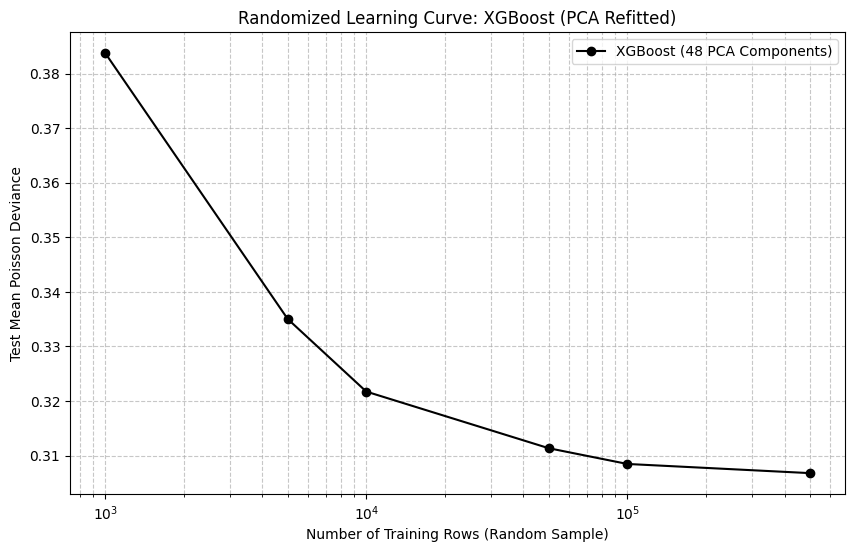

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_poisson_deviance

# Setup Data & Randomize
# ---------------------------------------------------------
train_data = np.load("embeddings/train_embeddings.npz")
test_data = np.load("embeddings/test_embeddings.npz")

# Extract arrays
X_raw_all = train_data['X']
y_raw_all = train_data['y']
exposure_raw_all = train_data['w']

# --- SHUFFLE LOGIC ---
np.random.seed(42)
indices = np.random.permutation(len(y_raw_all))

X_train_full = X_raw_all[indices]
y_train_full = y_raw_all[indices]
exposure_train_full = exposure_raw_all[indices]
# ---------------------

X_test_raw = test_data['X']
y_test = test_data['y']
exposure_test = test_data['w']

# Parameters for the curve
max_available = len(y_train_full)
train_sizes = [s for s in [1000, 5000, 10000, 50000, 100000, 500000] if s <= max_available]
deviances = []
n_components = 48

# XGBoost Parameters
xgb_params = {
    'objective': 'count:poisson',
    'learning_rate': 0.1,
    'max_depth': 6,
    'tree_method': 'hist',
    'nthread': -1
}

# Iterate through subset sizes
# ---------------------------------------------------------
for size in train_sizes:
    # Subset the shuffled training data
    X_sub = X_train_full[:size]
    y_sub = y_train_full[:size]
    exp_sub = exposure_train_full[:size]
    
    # Pipeline: Scale and PCA (re-fit per subset)
    scaler = StandardScaler()
    pca = PCA(n_components=n_components)
    
    # Pre-processing
    X_train_pca = pca.fit_transform(scaler.fit_transform(X_sub))
    X_test_pca = pca.transform(scaler.transform(X_test_raw))
    
    # Prepare DMatrix with base_margin (log exposure)
    # base_margin is the log of the offset/exposure for Poisson objective
    dtrain = xgb.DMatrix(X_train_pca, label=y_sub)
    dtrain.set_base_margin(np.log(exp_sub))
    
    dtest = xgb.DMatrix(X_test_pca, label=y_test)
    dtest.set_base_margin(np.log(exposure_test))
    
    # Train model
    bst = xgb.train(xgb_params, dtrain, num_boost_round=100)
    
    # Predict and Evaluate
    preds = bst.predict(dtest)
    mpd = mean_poisson_deviance(y_test, preds)
    deviances.append(mpd)
    
    print(f"Training Size {size}: Test Deviance = {mpd:.6f}")

# Plotting the Learning Curve
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, deviances, marker='o', color='black', 
         label=f'XGBoost ({n_components} PCA Components)')

plt.xscale('log')
plt.title('Randomized Learning Curve: XGBoost (PCA Refitted)')
plt.xlabel('Number of Training Rows (Random Sample)')
plt.ylabel('Test Mean Poisson Deviance')
plt.grid(True, linestyle='--', alpha=0.7, which='both')
plt.legend()
plt.show()